# 3D With hubble sphere = 0.30
Best fit curve when we define a maximum range where planets can occupy other planets. I believe I = 0.30 here

In [6]:
###### from math import log
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

data1 = np.loadtxt("3D_with_enclosure_static,curve,k=vary,sims=1,hb=5.0.dat")
k1 = data1[:, 0]
t1 = data1[:, 1]
# D_o = data1[0, 1]
beta = 32.24

print(t1)
print(k1)




[ 11.47113287  19.41473972  33.89555198  31.53450169  33.15674449
  45.577392    83.77953443  83.05190716 140.8697129  294.96856241
 565.0864044 ]
[0.         0.1        0.2        0.30000001 0.40000001 0.5
 0.60000002 0.69999999 0.80000001 0.89999998 0.94999999]


R^2 score: 0.9979


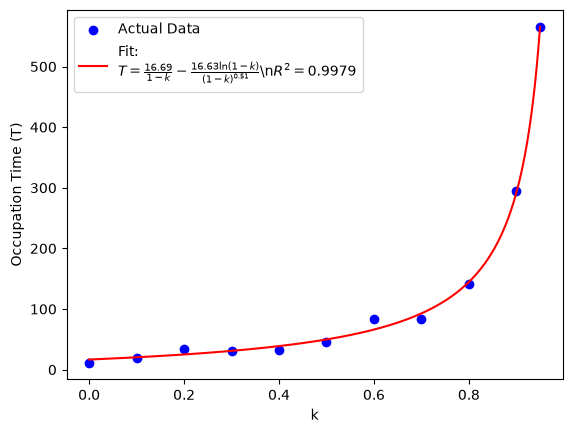

In [6]:

# 1. Define the 3-parameter Logistic Growth Model
def occupation_time(k,D,beta, gamma):
    return D / (1 - k) - beta * np.log(1 - k) / ((1 - k) ** gamma)


# Fit curve
p0 = [10,33, 1.0]
popt, _ = curve_fit(occupation_time, k1, t1, p0=p0)
D_fit, beta_fit, gamma_fit = popt


# --- Calculate Coefficient of Determination (R^2) ---
t1_pred = occupation_time(k1, *popt)
ss_res = np.sum((t1 - t1_pred) ** 2)  # Residual sum of squares
ss_tot = np.sum((t1 - np.mean(t1)) ** 2)  # Total sum of squares
r2 = 1 - (ss_res / ss_tot)  # R^2 score
6
print(f"R^2 score: {r2:.4f}")

# Label including R^2
eq_label = (
    rf"$T = \frac{{{D_fit:.2f}}}{{1 - k}} - "
    rf"\frac{{{float(beta_fit):.2f} \ln(1 - k)}}{{(1 - k)^{{{gamma_fit:.2f}}}}}$"
    rf"\n$R^2 = {r2:.4f}$"
)

k_dense = np.linspace(min(k1), max(k1), 1000)
t_fit = occupation_time(k_dense, *popt)

# Plot
plt.scatter(k1, t1, label="Actual Data", color="blue")
plt.plot(k_dense, t_fit, label=f"Fit:\n{eq_label}", color="red")
plt.xlabel("k")
plt.ylabel("Occupation Time (T)")
plt.legend()
plt.show()

R^2 score: 0.9995


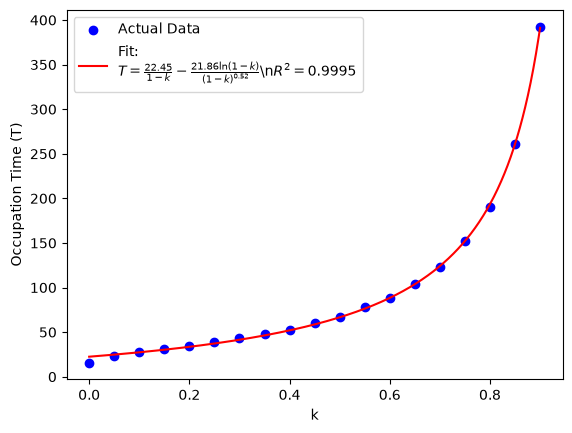

In [17]:

# 1. Define the 3-parameter Logistic Growth Model
def occupation_time(k,D,beta, gamma):
    return D / (1 - k) - beta * np.log(1 - k) / ((1 - k) ** gamma)


# Fit curve
p0 = [10,33, 1.0]
popt, _ = curve_fit(occupation_time, k1, t1, p0=p0)
D_fit, beta_fit, gamma_fit = popt


# --- Calculate Coefficient of Determination (R^2) ---
t1_pred = occupation_time(k1, *popt)
ss_res = np.sum((t1 - t1_pred) ** 2)  # Residual sum of squares
ss_tot = np.sum((t1 - np.mean(t1)) ** 2)  # Total sum of squares
r2 = 1 - (ss_res / ss_tot)  # R^2 score
6
print(f"R^2 score: {r2:.4f}")

# Label including R^2
eq_label = (
    rf"$T = \frac{{{D_fit:.2f}}}{{1 - k}} - "
    rf"\frac{{{float(beta_fit):.2f} \ln(1 - k)}}{{(1 - k)^{{{gamma_fit:.2f}}}}}$"
    rf"\n$R^2 = {r2:.4f}$"
)

k_dense = np.linspace(min(k1), max(k1), 1000)
t_fit = occupation_time(k_dense, *popt)

# Plot
plt.scatter(k1, t1, label="Actual Data", color="blue")
plt.plot(k_dense, t_fit, label=f"Fit:\n{eq_label}", color="red")
plt.xlabel("k")
plt.ylabel("Occupation Time (T)")
plt.legend()
plt.show()

# holding the D_fit parameter to be the time at k=0

R^2 score: 0.9978


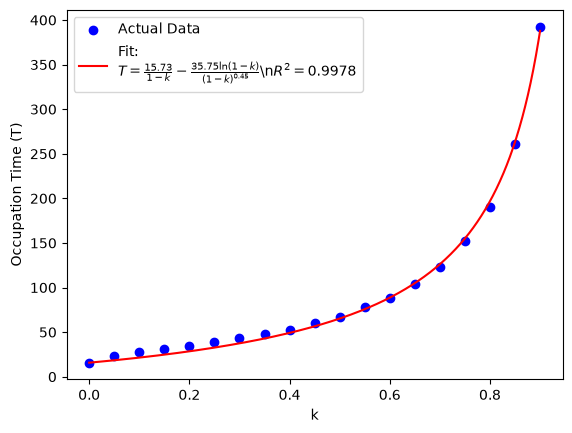

In [18]:
D = 15.73417052
# 1. Define the 3-parameter Logistic Growth Model
def occupation_time(k,beta, gamma):
    return D / (1 - k) - beta * np.log(1 - k) / ((1 - k) ** gamma)


# Fit curve
p0 = [33, 1.0]
popt, _ = curve_fit(occupation_time, k1, t1, p0=p0)
beta_fit, gamma_fit = popt


# --- Calculate Coefficient of Determination (R^2) ---
t1_pred = occupation_time(k1, *popt)
ss_res = np.sum((t1 - t1_pred) ** 2)  # Residual sum of squares
ss_tot = np.sum((t1 - np.mean(t1)) ** 2)  # Total sum of squares
r2 = 1 - (ss_res / ss_tot)  # R^2 score
6
print(f"R^2 score: {r2:.4f}")

# Label including R^2
eq_label = (
    rf"$T = \frac{{{D:.2f}}}{{1 - k}} - "
    rf"\frac{{{float(beta_fit):.2f} \ln(1 - k)}}{{(1 - k)^{{{gamma_fit:.2f}}}}}$"
    rf"\n$R^2 = {r2:.4f}$"
)

k_dense = np.linspace(min(k1), max(k1), 1000)
t_fit = occupation_time(k_dense, *popt)

# Plot
plt.scatter(k1, t1, label="Actual Data", color="blue")
plt.plot(k_dense, t_fit, label=f"Fit:\n{eq_label}", color="red")
plt.xlabel("k")
plt.ylabel("Occupation Time (T)")
plt.legend()
plt.show()

# Applied with OCTANT ENCLOSURE

In [5]:
###### from math import log
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

data1 = np.loadtxt("sims=10,k=vary, type=octant_enclosed.dat")
enclosed_k1 = data1[:, 0]
enclosed_t1 = data1[:, 1]
# D_o = data1[0, 1]
beta = 32.24
print(enclosed_t1)
print(enclosed_k1)


[ 28.56684193  34.37271532  46.34052689  52.70667152  67.15321922
  67.15321922  92.05776186  92.05776186 120.57586314 211.23518745
 391.54521732  18.64788453  18.64788453]
[0.1        0.2        0.30000001 0.40000001 0.5        0.5
 0.60000002 0.60000002 0.69999999 0.80000001 0.89999998 0.
 0.        ]


R^2 score: -14.4769


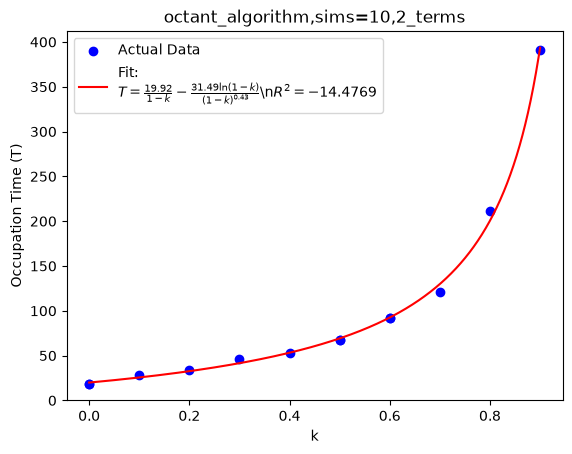

In [6]:

# 1. Define the 3-parameter Logistic Growth Model
def occupation_time(k,D,beta, gamma):
    return D / (1 - k) - beta * np.log(1 - k) / ((1 - k) ** gamma)


# Fit curve
p0 = [10,33, 1.0]
popt, _ = curve_fit(occupation_time, enclosed_k1, enclosed_t1, p0=p0)
D_fit, beta_fit, gamma_fit = popt


# --- Calculate Coefficient of Determination (R^2) ---
t1_pred = occupation_time(k1, *popt)
ss_res = np.sum((t1 - t1_pred) ** 2)  # Residual sum of squares
ss_tot = np.sum((t1 - np.mean(t1)) ** 2)  # Total sum of squares
r2 = 1 - (ss_res / ss_tot)  # R^2 score
6
print(f"R^2 score: {r2:.4f}")

# Label including R^2
eq_label = (
    rf"$T = \frac{{{D_fit:.2f}}}{{1 - k}} - "
    rf"\frac{{{float(beta_fit):.2f} \ln(1 - k)}}{{(1 - k)^{{{gamma_fit:.2f}}}}}$"
    rf"\n$R^2 = {r2:.4f}$"
)

k_dense = np.linspace(min(k1), max(k1), 1000)
t_fit = occupation_time(k_dense, *popt)

# Plot
plt.scatter(enclosed_k1, enclosed_t1, label="Actual Data", color="blue")
plt.plot(k_dense, t_fit, label=f"Fit:\n{eq_label}", color="red")
plt.xlabel("k")
plt.ylabel("Occupation Time (T)")
plt.title("octant_algorithm,sims=10,2_terms")
plt.legend()
plt.show()

# Dropping the 2nd term in the octant algorithm

Fitted D: 38.4311
R^2 score: 0.9862


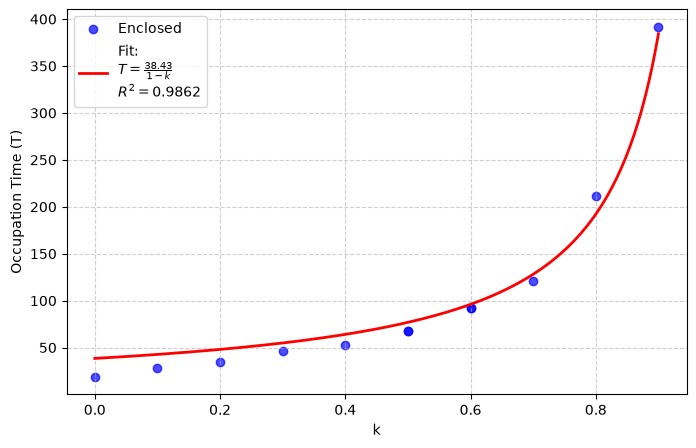

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Model fitting D with beta = 0
def occupation_time(k, D_fit):
    return D_fit / (1.0 - k)

# Fit curve to find optimal D
popt, _ = curve_fit(occupation_time, enclosed_k1, enclosed_t1, p0=[18.0])
D_fit = popt[0]

# Predictions and R^2
t1_pred = occupation_time(enclosed_k1, D_fit)
ss_res = np.sum((enclosed_t1 - t1_pred) ** 2)
ss_tot = np.sum((enclosed_t1 - np.mean(enclosed_t1)) ** 2)
r2 = 1.0 - (ss_res / ss_tot)

print(f"Fitted D: {D_fit:.4f}")
print(f"R^2 score: {r2:.4f}")

# Plotting
k_dense = np.linspace(min(enclosed_k1), max(enclosed_k1), 1000)
t_fit = occupation_time(k_dense, D_fit)

eq_label = rf"$T = \frac{{{D_fit:.2f}}}{{1 - k}}$" + f"\n$R^2 = {r2:.4f}$"

plt.figure(figsize=(8, 5))
plt.scatter(enclosed_k1, enclosed_t1, label="Enclosed", color="blue", alpha=0.7)
plt.plot(k_dense, t_fit, label=f"Fit:\n{eq_label}", color="red", linewidth=2)
plt.xlabel("k")
plt.ylabel("Occupation Time (T)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# 3D Version. max_range = 0.90, k = vary, sims = 500
I put a maximum range to where planets can reach other planets.


Fitted D: 10.4192
R^2 score: 0.9996


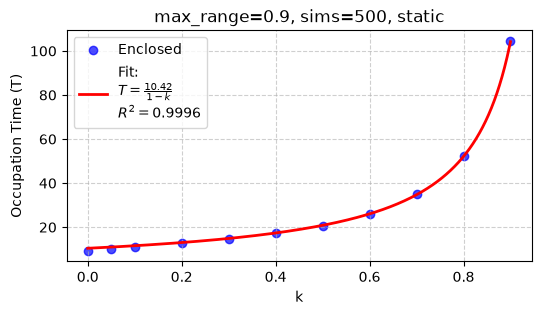

In [2]:
###### from math import log
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

data1 = np.loadtxt("3D_with_enclosure_static,curve,k=vary,sims=500,hb=0.9.dat")
k1 = data1[:, 0]
t1 = data1[:, 1]
t_de = data1[:,2]
t_m = data1[:,3]

# Model fitting D with beta = 0
def occupation_time(k, D_fit):
    return D_fit / (1.0 - k)

# Fit curve to find optimal D
popt, _ = curve_fit(occupation_time, k1, t1, p0=[18.0])
D_fit = popt[0]

# Predictions and R^2
t1_pred = occupation_time(k1, D_fit)
ss_res = np.sum((t1 - t1_pred) ** 2)
ss_tot = np.sum((t1 - np.mean(t1)) ** 2)
r2 = 1.0 - (ss_res / ss_tot)

print(f"Fitted D: {D_fit:.4f}")
print(f"R^2 score: {r2:.4f}")

# Plotting
k_dense = np.linspace(min(k1), max(k1), 1000)
t_fit = occupation_time(k_dense, D_fit)

eq_label = rf"$T = \frac{{{D_fit:.2f}}}{{1 - k}}$" + f"\n$R^2 = {r2:.4f}$"

plt.figure(figsize=(6,3))
plt.scatter(k1, t1, label="Enclosed", color="blue", alpha=0.7)
plt.plot(k_dense, t_fit, label=f"Fit:\n{eq_label}", color="red", linewidth=2)
plt.xlabel("k")
plt.ylabel("Occupation Time (T)")
plt.legend()
plt.title("max_range=0.9, sims=500, static")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()



--- Fit for $t_s$ ---
D = 9.7117, beta = 1.3292, gamma = 0.3771
R^2 = 0.9999

--- Fit for $t_{de}$ ---
D = 15.5489, beta = -29.0359, gamma = -0.8410
R^2 = 0.9932

--- Fit for $t_m$ ---
D = 10.2439, beta = 0.5707, gamma = 1.3884
R^2 = 0.9999



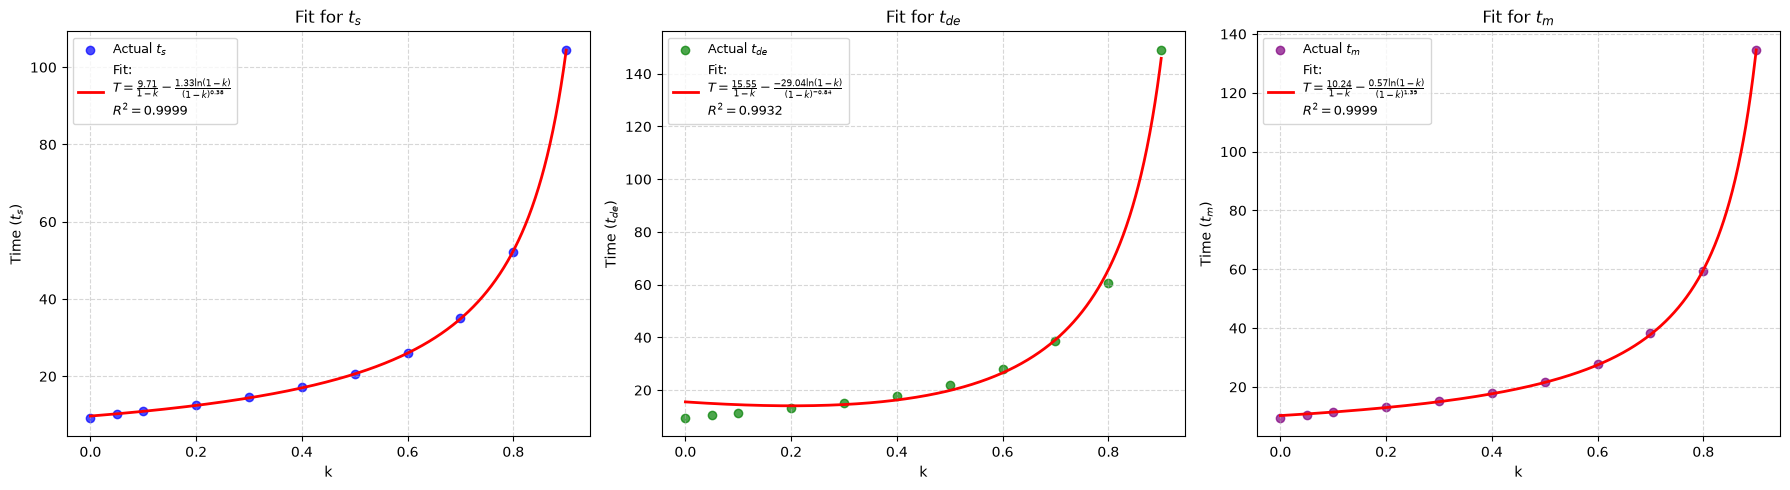

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# Load data
data1 = np.loadtxt("3D_with_enclosure_static,curve,k=vary,sims=500,hb=0.9.dat")
k1 = data1[:, 0]
targets = {
    "$t_s$": data1[:, 1],
    "$t_{de}$": data1[:, 2],
    "$t_m$": data1[:, 3],
}

# Define the 3-parameter model
def occupation_time(k, D, beta, gamma):
    return D / (1 - k) - beta * np.log(1 - k) / ((1 - k) ** gamma)

# Dense k array for smooth curve plotting
k_dense = np.linspace(min(k1), max(k1), 1000)

# Setup subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

# Colors for each subplot
colors = ["blue", "green", "purple"]
initial_p0 = [10, 33, 1.0]

for ax, (name, y_data), color in zip(axes, targets.items(), colors):
    # Fit curve
    popt, _ = curve_fit(occupation_time, k1, y_data, p0=initial_p0)
    D_fit, beta_fit, gamma_fit = popt

    # Calculate R^2
    y_pred = occupation_time(k1, *popt)
    ss_res = np.sum((y_data - y_pred) ** 2)
    ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
    r2 = 1 - (ss_res / ss_tot)

    # Print fitted parameters
    print(
        f"--- Fit for {name} ---\n"
        f"D = {D_fit:.4f}, beta = {beta_fit:.4f}, gamma = {gamma_fit:.4f}\n"
        f"R^2 = {r2:.4f}\n"
    )

    # Generate equation label
    eq_label = (
        rf"$T = \frac{{{D_fit:.2f}}}{{1 - k}} - "
        rf"\frac{{{beta_fit:.2f} \ln(1 - k)}}{{(1 - k)^{{{gamma_fit:.2f}}}}}$"
        f"\n$R^2 = {r2:.4f}$"
    )

    # Plot data and best fit
    t_fit = occupation_time(k_dense, *popt)
    ax.scatter(k1, y_data, label=f"Actual {name}", color=color, alpha=0.7)
    ax.plot(k_dense, t_fit, label=f"Fit:\n{eq_label}", color="red", linewidth=2)

    ax.set_xlabel("k")
    ax.set_ylabel(f"Time ({name})")
    ax.set_title(f"Fit for {name}")
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# 3D version of the max range mechanism after 500 sims
500 simulations for max range = 0.9 and different values of k and h

--- Fit Results ---
N_0 = 5175.3140 ± 3.1029
k   = 0.3094 ± 0.0004
t_0 = 23.8241 ± 0.0052
R²  = 0.9990


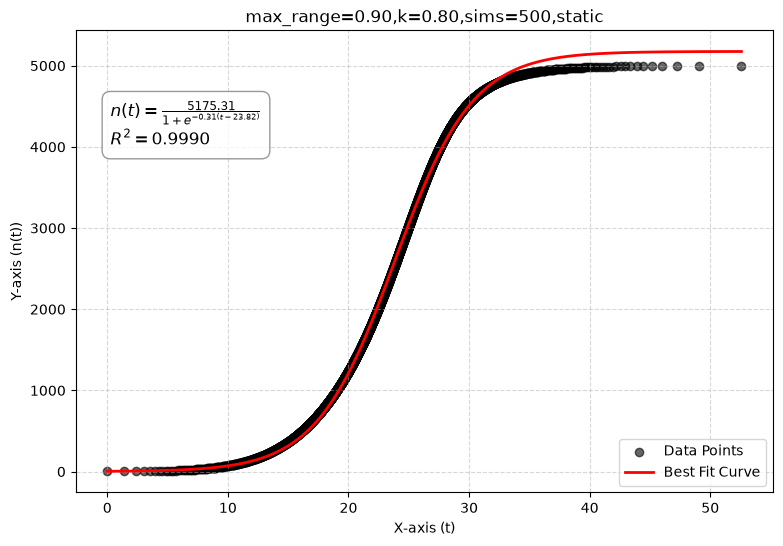

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# 1. Define the 3-parameter function
def logistic_model(t, N_0, k, t_0):
    return N_0 / (1 + np.exp(-k * (t - t_0)))

# 2. Load data from the .dat file
data = np.loadtxt("average_n_vs_t,sims=500,k=0.80,H=0.02.dat")

# Extract columns (First column is y-axis, second column is x-axis)
y_data = data[:, 0]
t_data = data[:, 1]  # x-axis represents independent variable 't'

# 3. Provide initial guesses for the parameters [N_0, k, t_0]
initial_guesses = [max(y_data), 1.0, np.median(t_data)]

# 4. Perform the curve fit
popt, pcov = curve_fit(
    logistic_model, t_data, y_data, p0=initial_guesses, maxfev=10000
)

# Extract optimized parameters
N_0_opt, k_opt, t_0_opt = popt
perr = np.sqrt(np.diag(pcov))  # Standard deviations of the parameters

# 5. Calculate R^2 (Coefficient of Determination)
y_pred = logistic_model(t_data, *popt)
ss_res = np.sum((y_data - y_pred) ** 2)
ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
r_squared = 1 - (ss_res / ss_tot)

# 6. Print out the results including R^2
print("--- Fit Results ---")
print(f"N_0 = {N_0_opt:.4f} ± {perr[0]:.4f}")
print(f"k   = {k_opt:.4f} ± {perr[1]:.4f}")
print(f"t_0 = {t_0_opt:.4f} ± {perr[2]:.4f}")
print(f"R²  = {r_squared:.4f}")

# 7. Generate smooth curves for plotting the fit
t_fit = np.linspace(min(t_data), max(t_data), 500)
y_fit = logistic_model(t_fit, *popt)

# 8. Plot the raw data and the fitted function
plt.figure(figsize=(9, 6))
plt.scatter(t_data, y_data, color="black", label="Data Points", alpha=0.6)
plt.plot(t_fit, y_fit, color="red", linewidth=2, label="Best Fit Curve")

# --- NEW: 9. Display the specific fitted equation directly on the screen ---
# Constructing a clean LaTeX string using your numerical results
equation_text = (
    f"$n(t) = \\frac{{{N_0_opt:.2f}}}{{1 + e^{{-{k_opt:.2f}(t - {t_0_opt:.2f})}}}}$\n"
    f"$R^2 = {r_squared:.4f}$"
)

# Place the text box on the plot. 
# transform=plt.gca().transAxes anchors coordinates to the axis frame (0 to 1) 
# so it stays safely in the upper-left quadrant regardless of your raw data scale.
plt.text(
    0.05, 0.85, 
    equation_text, 
    transform=plt.gca().transAxes, 
    fontsize=12, 
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.8)
)

# Formatting the plot
plt.xlabel("X-axis (t)")
plt.ylabel("Y-axis (n(t))")
plt.title("max_range=0.90,k=0.80,sims=500,static")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)

# Show the plot
plt.show()


comparison of the plots. 500 sims 

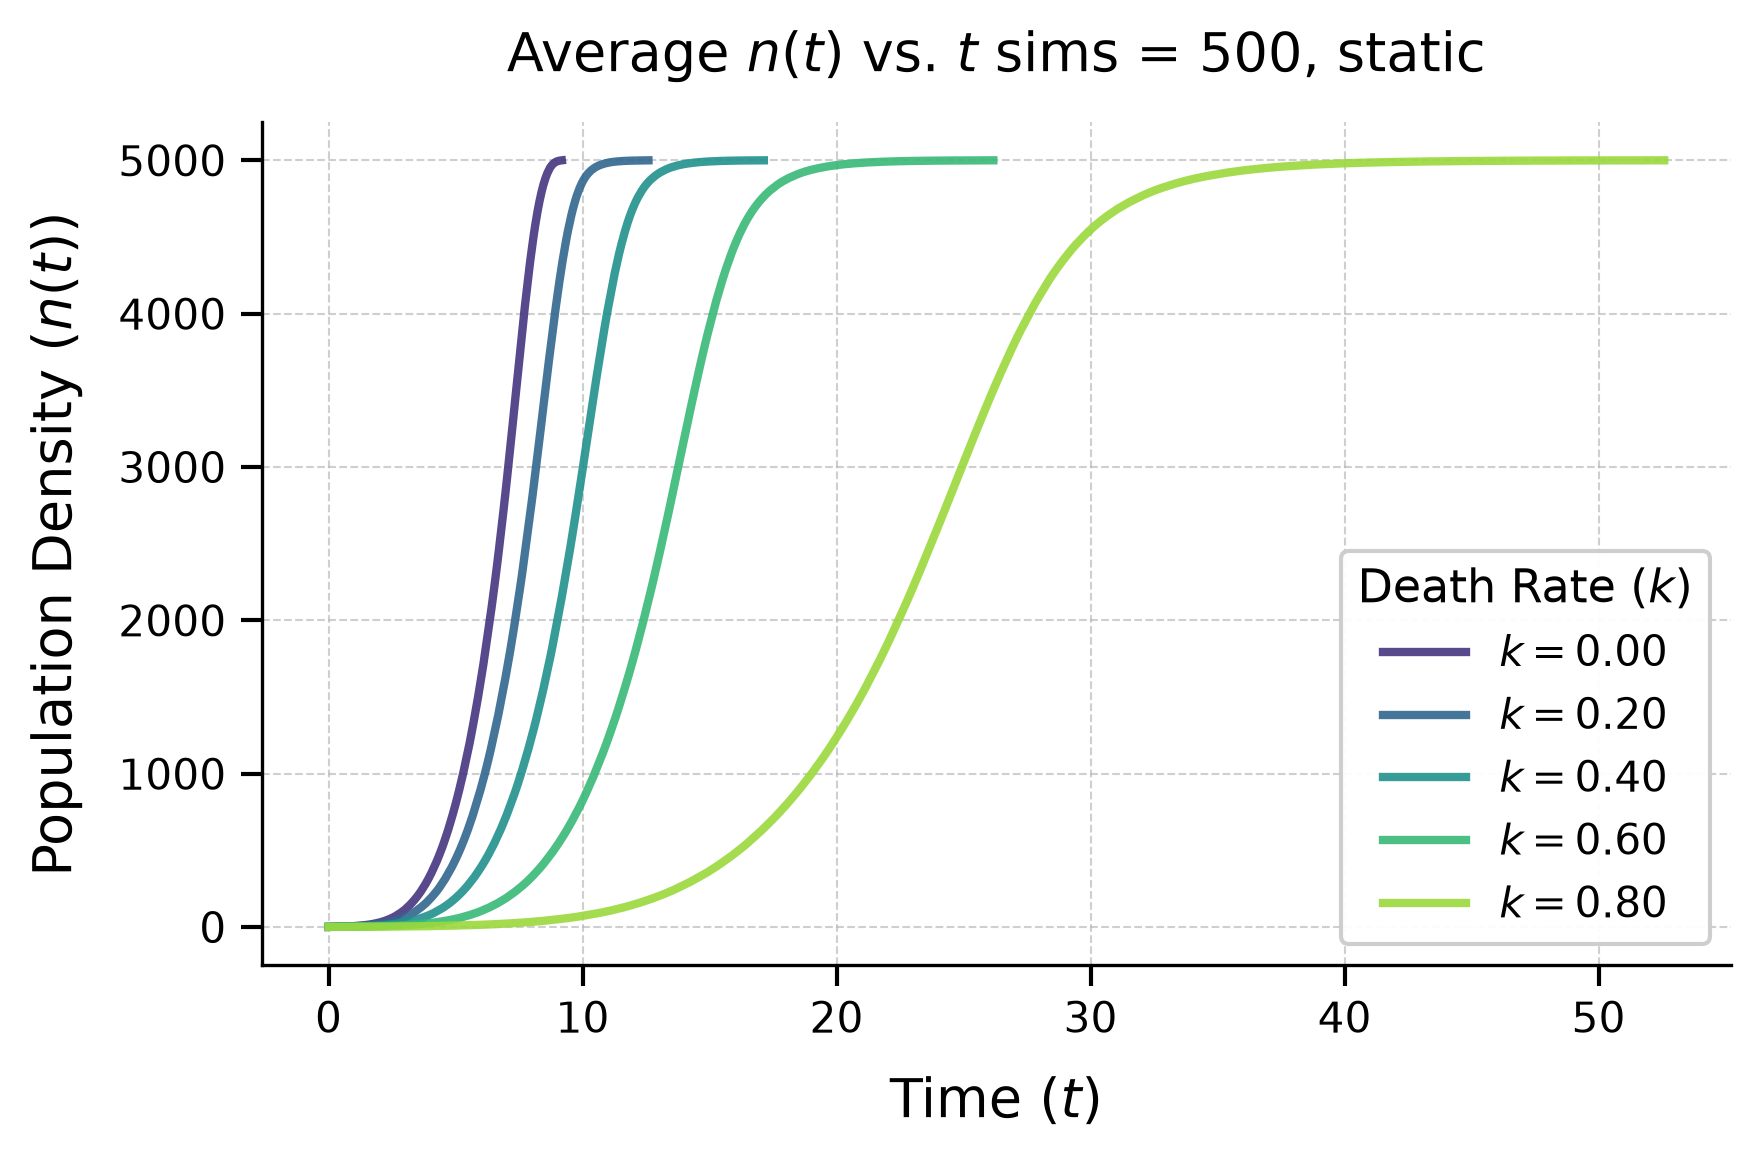

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Set global styling for publication-quality typography and proportions
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.size": 11,
        "axes.labelsize": 13,
        "axes.titlesize": 13,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.titlesize": 14,
    }
)

# 2. File definitions and math-formatted labels
filenames = [
    "average_n_vs_t,sims=500,k=0,H=0.02.dat",
    "average_n_vs_t,sims=500,k=0.20,H=0.02.dat",
    "average_n_vs_t,sims=500,k=0.40,H=0.02.dat",
    "average_n_vs_t,sims=500,k=0.60,H=0.02.dat",
    "average_n_vs_t,sims=500,k=0.80,H=0.02.dat",
]

labels = ["$k = 0.00$", "$k = 0.20$", "$k = 0.40$", "$k = 0.60$", "$k = 0.80$"]

# 3. Create a sequential color map since 'k' increases monotonically
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(filenames)))

# 4. Initialize object-oriented plot (high DPI for sharp rendering)
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# 5. Loop and plot data
for file, label, color in zip(filenames, labels, colors):
    data = np.loadtxt(file)
    y_data = data[:, 0]
    t_data = data[:, 1]

    ax.plot(t_data, y_data, label=label, color=color, linewidth=2, alpha=0.9)

# 6. Formatting titles and labels using LaTeX math syntax
ax.set_xlabel("Time ($t$)", labelpad=8)
ax.set_ylabel("Population Density ($n(t)$)", labelpad=8)
ax.set_title(
    "Average $n(t)$ vs. $t$ sims = 500, static", pad=12
)

# 7. Clean up grid, spines, and ticks
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(direction="out", length=5, width=1)

# 8. Add a clean, framed legend
ax.legend(
    title="Death Rate ($k$)",
    loc="best",
    frameon=True,
    facecolor="white",
    edgecolor="#CCCCCC",
    framealpha=0.95,
)

plt.tight_layout()
plt.show()

# Max enclosure = 0.9 for DARK-ENERGY dominated 
Plots related to the dark-energy dominated framework. 

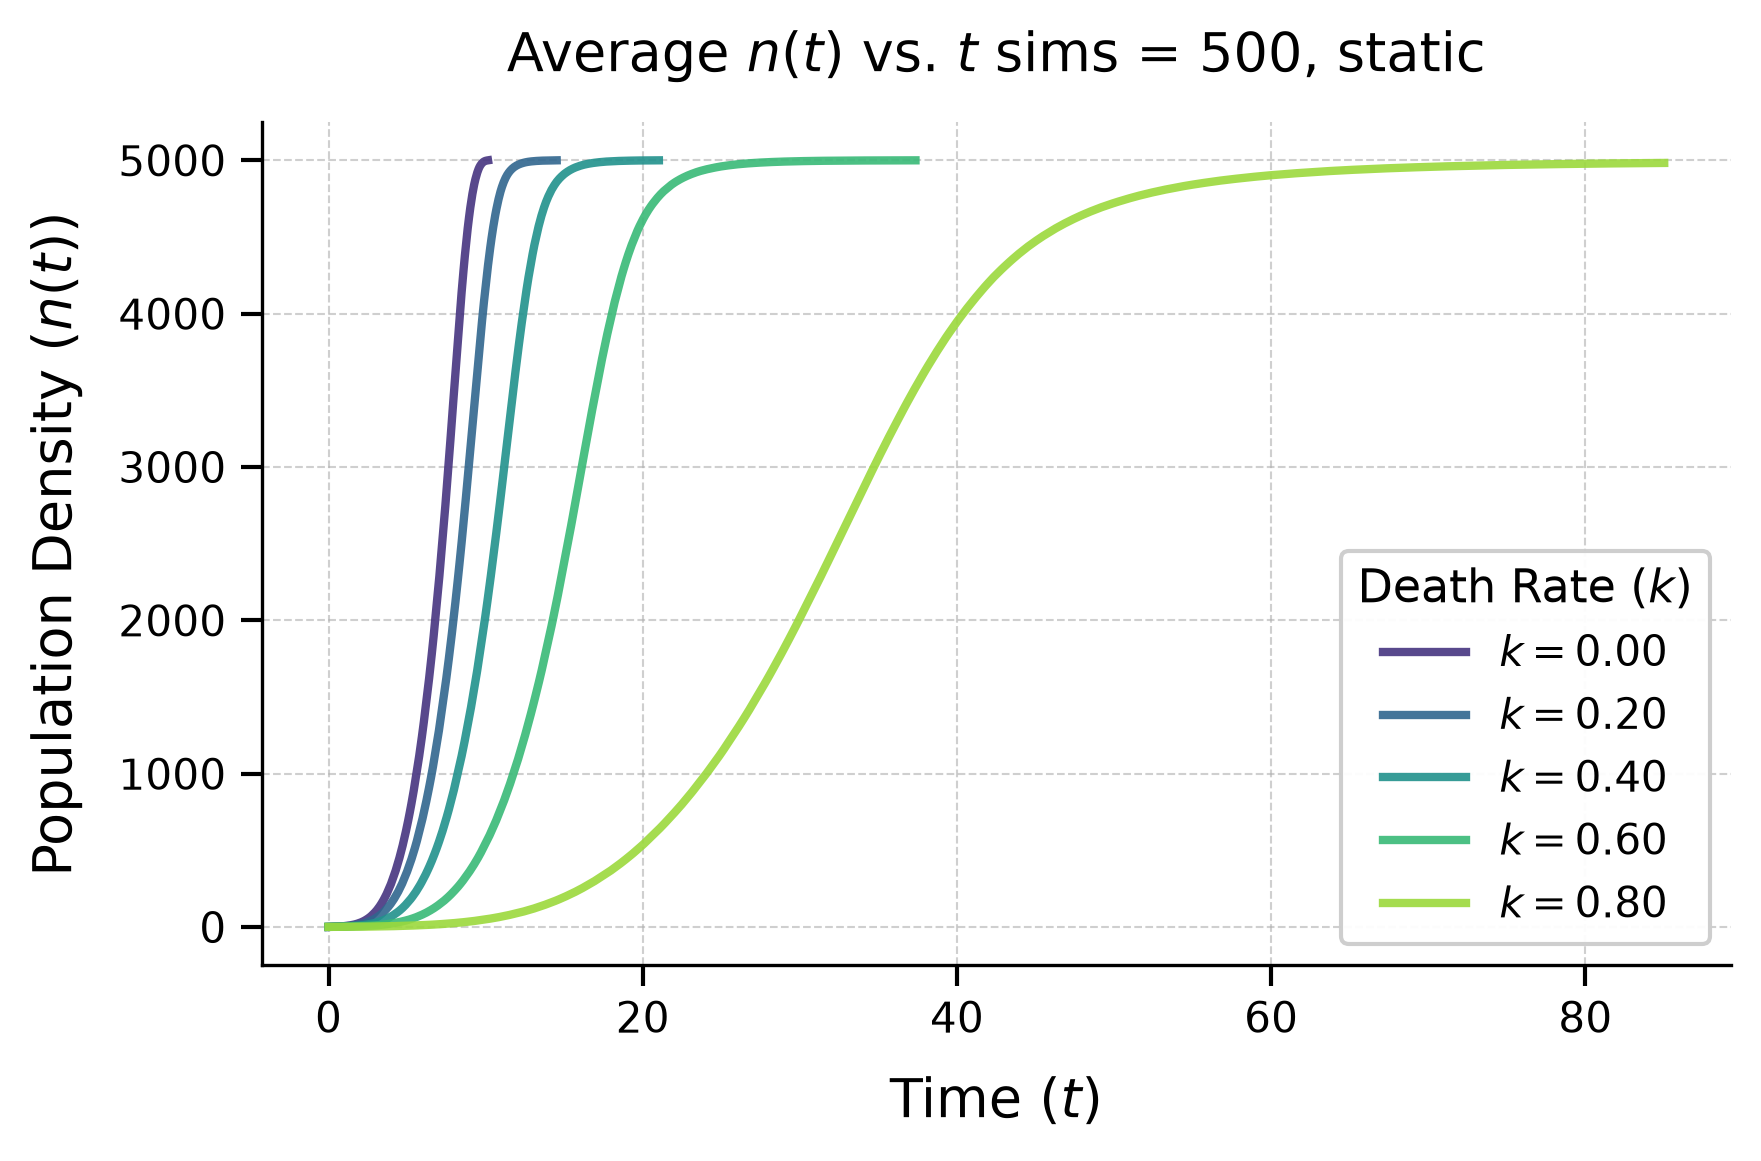

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Set global styling for publication-quality typography and proportions
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.size": 11,
        "axes.labelsize": 13,
        "axes.titlesize": 13,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.titlesize": 14,
    }
)

# 2. File definitions and math-formatted labels
filenames = [
    "average_n_vs_t,sims=500,k=0,H=0.02.dat",
    "average_n_vs_t,sims=500,k=0.20,H=0.02.dat",
    "average_n_vs_t,sims=500,k=0.40,H=0.02.dat",
    "average_n_vs_t,sims=500,k=0.60,H=0.02.dat",
    "average_n_vs_t,sims=500,k=0.80,H=0.02.dat",
]

labels = ["$k = 0.00$", "$k = 0.20$", "$k = 0.40$", "$k = 0.60$", "$k = 0.80$"]

# 3. Create a sequential color map since 'k' increases monotonically
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(filenames)))

# 4. Initialize object-oriented plot (high DPI for sharp rendering)
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# 5. Loop and plot data
for file, label, color in zip(filenames, labels, colors):
    data = np.loadtxt(file)
    y_data = data[:, 0]
    t_data = data[:, 2]

    ax.plot(t_data, y_data, label=label, color=color, linewidth=2, alpha=0.9)

# 6. Formatting titles and labels using LaTeX math syntax
ax.set_xlabel("Time ($t$)", labelpad=8)
ax.set_ylabel("Population Density ($n(t)$)", labelpad=8)
ax.set_title(
    "Average $n(t)$ vs. $t$ sims = 500, static", pad=12
)

# 7. Clean up grid, spines, and ticks
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(direction="out", length=5, width=1)

# 8. Add a clean, framed legend
ax.legend(
    title="Death Rate ($k$)",
    loc="best",
    frameon=True,
    facecolor="white",
    edgecolor="#CCCCCC",
    framealpha=0.95,
)

plt.tight_layout()
plt.show()

--- Fit Results ---
N_0 = 436.8991 ± 2.9751
k   = 0.1412 ± 0.0005
t_0 = 36.1359 ± 0.0933
R²  = 0.9998


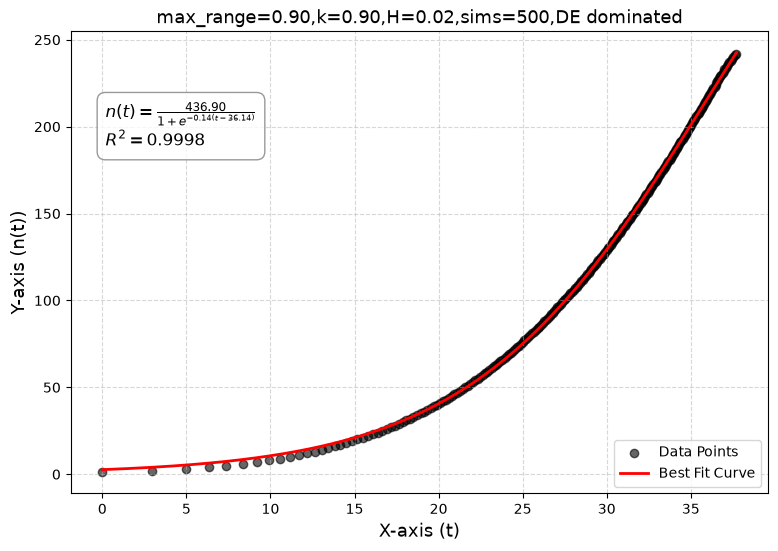

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# 1. Define the 3-parameter function
def logistic_model(t, N_0, k, t_0):
    return N_0 / (1 + np.exp(-k * (t - t_0)))

# 2. Load data from the .dat file
data = np.loadtxt("average_n_vs_t,sims=500,k=0.90,H=0.02.dat")

# Extract columns (First column is y-axis, second column is x-axis)
y_data = data[0:242, 0]
t_data = data[0:242, 2]  # Sliced to match y_data length

# Filter out NaN values from both x and y data
mask = ~np.isnan(t_data) & ~np.isnan(y_data)
t_data = t_data[mask]
y_data = y_data[mask]

# 3. Provide initial guesses for the parameters [N_0, k, t_0]
initial_guesses = [max(y_data), 1.0, np.median(t_data)]

# 4. Perform the curve fit
popt, pcov = curve_fit(
    logistic_model, t_data, y_data, p0=initial_guesses, maxfev=10000
)

# Extract optimized parameters
N_0_opt, k_opt, t_0_opt = popt
perr = np.sqrt(np.diag(pcov))  # Standard deviations of the parameters

# 5. Calculate R^2 (Coefficient of Determination)
y_pred = logistic_model(t_data, *popt)
ss_res = np.sum((y_data - y_pred) ** 2)
ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
r_squared = 1 - (ss_res / ss_tot)

# 6. Print out the results including R^2
print("--- Fit Results ---")
print(f"N_0 = {N_0_opt:.4f} ± {perr[0]:.4f}")
print(f"k   = {k_opt:.4f} ± {perr[1]:.4f}")
print(f"t_0 = {t_0_opt:.4f} ± {perr[2]:.4f}")
print(f"R²  = {r_squared:.4f}")

# 7. Generate smooth curves for plotting the fit
t_fit = np.linspace(min(t_data), max(t_data), 500)
y_fit = logistic_model(t_fit, *popt)

# 8. Plot the raw data and the fitted function
plt.figure(figsize=(9, 6))
plt.scatter(t_data, y_data, color="black", label="Data Points", alpha=0.6)
plt.plot(t_fit, y_fit, color="red", linewidth=2, label="Best Fit Curve")

# --- 9. Display the specific fitted equation directly on the screen ---
equation_text = (
    f"$n(t) = \\frac{{{N_0_opt:.2f}}}{{1 + e^{{-{k_opt:.2f}(t - {t_0_opt:.2f})}}}}$\n"
    f"$R^2 = {r_squared:.4f}$"
)

plt.text(
    0.05, 0.85, 
    equation_text, 
    transform=plt.gca().transAxes, 
    fontsize=12, 
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.8)
)

# Formatting the plot
plt.xlabel("X-axis (t)")
plt.ylabel("Y-axis (n(t))")
plt.title("max_range=0.90,k=0.90,H=0.02,sims=500,DE dominated")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)

# Show the plot
plt.show()

# CPATH PLOT
This plots the cumulative path taken by each planet in spreading the civilization. Max range = 0.9 

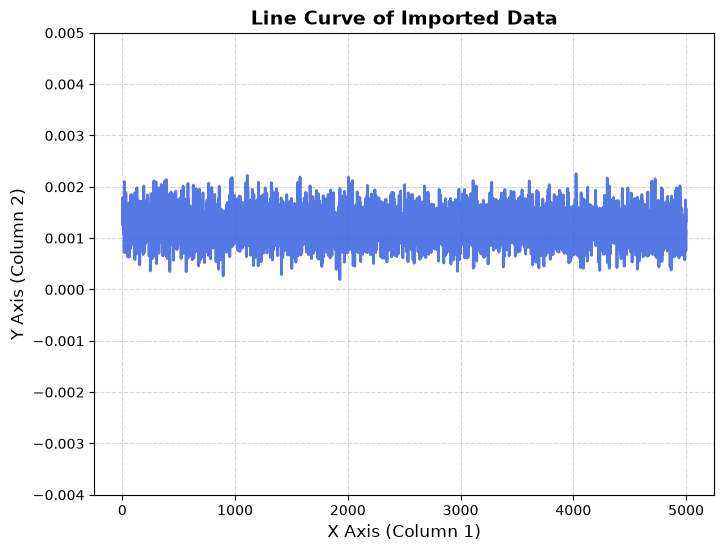

In [11]:
import os
import matplotlib.pyplot as plt
import numpy as np

# 1. Define your filename
data_file = 'cpath,sims=500,k=0.0,H=0.02.dat' 

# Safety check to confirm file existence
if not os.path.exists(data_file):
    raise FileNotFoundError(f"Could not find '{data_file}'. Make sure it is in your active folder.")

# 2. Import the data 
data = np.loadtxt(data_file)

# 3. Split the columns into X and Y axes
x_values = data[:, 0]  # First column
y_values = data[:, 1]  # Second column

# 4. Generate the continuous line curve plot
plt.figure(figsize=(8, 6))
# FIX: Changed plt.scatter to plt.plot for a continuous line curve
plt.plot(x_values, y_values, color='royalblue', linewidth=2.0, alpha=0.9)

# 5. Label formatting
# Updated title to reflect the line chart type
plt.title("Line Curve of Imported Data", fontsize=14, fontweight='bold')
plt.xlabel("X Axis (Column 1)", fontsize=12)
plt.ylabel("Y Axis (Column 2)", fontsize=12)
plt.ylim(-0.004, 0.005)
plt.grid(True, linestyle='--', alpha=0.5) # Added grid lines for easier baseline tracking

# 6. Display the plot window
plt.show()
